In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly
import math 


# 1. Business Understanding

The purpose of this project is to predict whether an online shopper is likely to complete a purchase based on their browsing behaviour during a website session. By identifying customers with high purchase intention, an online business can provide more relevant product recommendations, promotions or reminders. This may help improve conversion rates, reduce unnecessary marketing costs and create a more personalised shopping experience. my final goal here is i hope to pass out a % or so call a chance of wheather this customer might buy or not buy the items. This is a classification problem and the dataset also is only True/Flase for the target(revenue) but the result still can be displayed as %. This is still a binary classification problem because the target contains two categories True/False(purchase and non-purchase).The probability percentage provides more detail about the strength of the prediction, but it does not change the problem into regression.

# 2. Data Understanding

Before anything could start we have to know why use this dataset and if it is save to use(what makes a good datasets)
So here i am using a data set from link:https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset and it is call Online Shoppers Purchasing Intention Dataset. and i will be giving edvidence on why this dataset is good or safe to use

1) it is hosted by the official UCI Machine Learning Repository
2) it has the creator C.Sakar and Yomi Kastro's names 
3) it has permanent DOI which let people locate the official datasets 
4) it is linked to a published research paper (extemly imporant) Springer’s    Neural Computing and Applications, volume 31, pages 6893–6908.
5) the data collection was well explained 
6) each featurs is well explain and it tells why it might affect results 
7) it has a legal licence 
   -Creative Commons Attribution 4.0 International
   -CC BY 4.0

## 2.1 Load dataset

In [3]:
# just getting the data and have a look frist 
FILE_PATH = "online_shoppers_intention.csv"
df = pd.read_csv(FILE_PATH) 
df 

# this is a copy of the dataset this allow us to check and compare at anypoint of the project 
copy_df = df.copy()

# what are these colunms ?
#Administrative: the number of pages the user visit 
#Administrative_Duration: time spent(s) on the page
#Informational: The number of pages the user visited to read about the company (e.g. about us, contact pages, or privacy policies).
#Informational_Duration:  time spent on those pages
#ProductRelated: The number of pages the user visited to look at actual items, browse categories, or check product details.
#ProductRelated_Duration: The total time (s) the user spent looking at products.

#BounceRates: The percentage of visitors who entered the website on this page and immediately left
#ExitRates: The percentage of times a specific page was the very last page a user looked at before closing the tab or leaving the website entirely.
#PageValues: Pages that a user visits right before making a purchase get a high score; pages that rarely lead to sales get a zero.

#SpecialDay: A rating from 0.0 to 1.0 showing how close the shopping session is to a major holiday. 1.0 means it's the peak shopping day.
#Month: The month of the year when the session occurred .
#Weekend: A True or False flag showing if the user was shopping on a Saturday or Sunday.

#OperatingSystems: An anonymous ID number representing the software the user's device runs on (e.g., Windows, macOS, Android).
#Browser: An anonymous ID number representing the web browser used (e.g., Chrome, Safari, Firefox).
#Region: representing the geographic location or territory the user is browsing from.
#TrafficType: An anonymous ID number representing how the user found the website (e.g., via a Google search, a paid Instagram ad, or typing the link directly).
#VisitorType: Categorizes the user as a New_Visitor, Returning_Visitor, or Other.

# traget: revenue - True/False 

In [ ]:
# get the rows and col 
number_of_rows, number_of_columns = df.shape
print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)


number_of_features = number_of_columns - 1    # -1 as the target is not counted 
row_feature_ratio = number_of_rows / number_of_features

print(f"Approximately {row_feature_ratio:.1f} rows for every feature.")

# informations get:
# the row to feature ratio here tells me how many examples the model get to look at for each features a 752.3 is ok and 
# from out school notes the guid line is that the rows might be 10x of the features so at this point the rows and cols matched it. PASSED
# as i was doing and learning i came back here and drop down this is the data quantity which is ok 

Number of rows: 12330
Number of columns: 18
Approximately 725.3 rows for every feature.


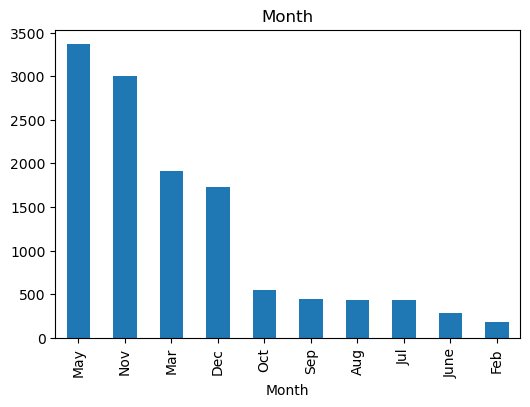

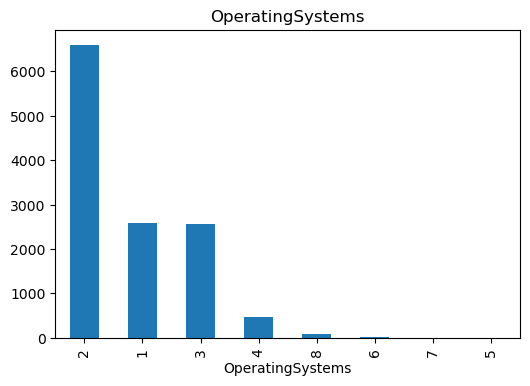

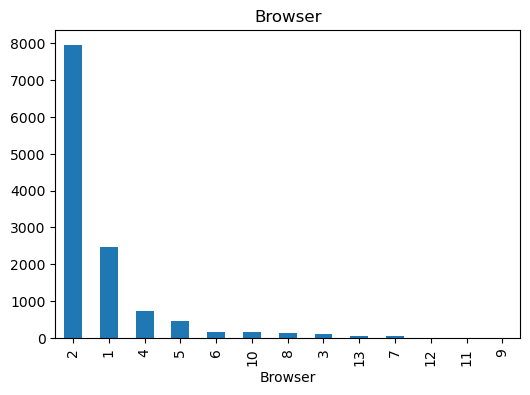

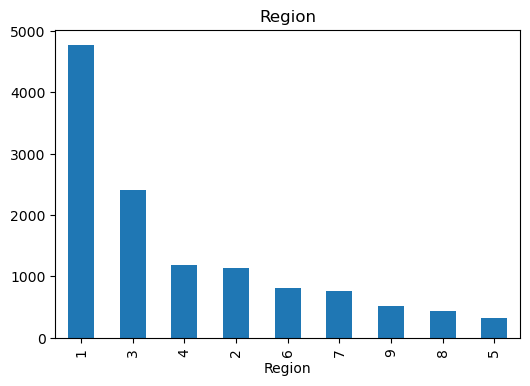

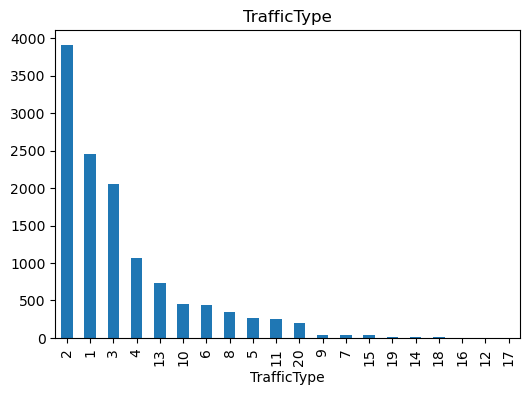

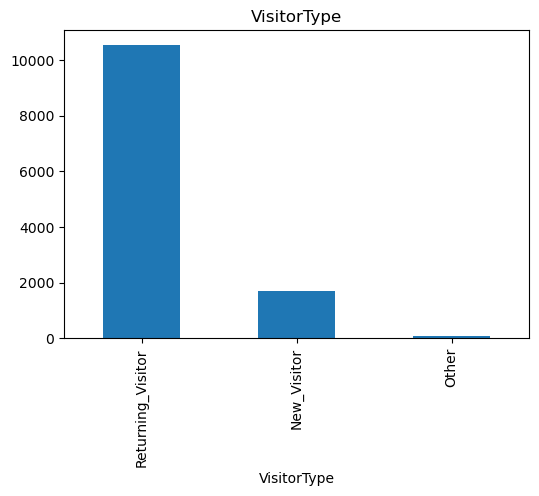

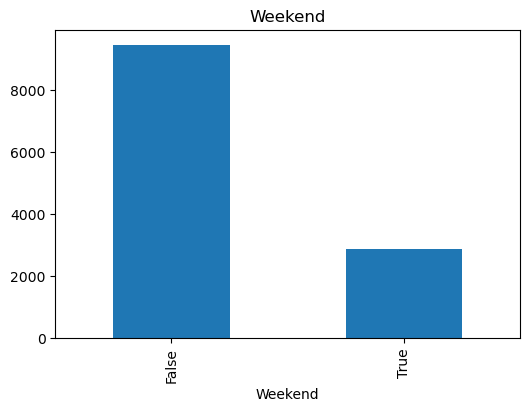

In [ ]:
import matplotlib.pyplot as plt

categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

# this part we are checking the diversity of the dataset 
# at frist this part i was thinking if i should remove the browser col as how can that even affect the target
# but when i think deeper it might have some correclation like safari are i phone user they might shop during 
# leisure time, so we will keep it for now 
# at this point i have done the 4 check: Relevant,quality,quantity and diversity

In [5]:
## Understand the type of variable for each column
data_type_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "example_values": [
        df[column].drop_duplicates().head(5).tolist()
        for column in df.columns
    ]
})

display(data_type_report)

#insights we know now:
#1)
#  The OperatingSystems, Browser, Region, and TrafficType.(1, 2, 3, 4), but the data_type is correctly listed as category.
#  this means the machine will not treat them as order but it is a group which is good 
# 2)
#  There is a lot of 0.0 for Administrative	Administrative_Duration	Informational	Informational_Duration 
#  this tells us that normal customer dont go to these page and won't even stay and also how the graph might look like later 
#3)
#  BounceRates, ExitRates, and PageValues are all float64 these are important indicators from the col understanding

# things to do later(not fully but now we at least know some)
#1)Encode Categorical Variables(visitory type,month and weekend) machine learning algorithms only understand numbers using One-Hot Encoding or other endcoing 

,data_type,example_values
Administrative,int64,"[0, 1, 2, 4, 12]"
Administrative_Duration,float64,"[0.0, 53.0, 64.6, 6.0, 18.0]"
Informational,int64,"[0, 1, 2, 4, 16]"
Informational_Duration,float64,"[0.0, 120.0, 16.0, 94.0, 93.0]"
ProductRelated,int64,"[1, 2, 10, 19, 0]"
ProductRelated_Duration,float64,"[0.0, 64.0, 2.666666667, 627.5, 154.2166667]"
BounceRates,float64,"[0.2, 0.0, 0.05, 0.02, 0.015789474]"
ExitRates,float64,"[0.2, 0.1, 0.14, 0.05, 0.024561404]"
PageValues,float64,"[0.0, 54.17976426, 19.44707913, 38.30849268, 2..."
SpecialDay,float64,"[0.0, 0.4, 0.8, 1.0, 0.2]"


In [6]:
## Check for missing data
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_report = missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_report)
# ok this dataset was already told that it has no missing values but it is still important to check 

,missing_count,missing_percentage
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


In [7]:
# unique col 
unique_value_report = pd.DataFrame({
    "unique_count": df.nunique(dropna=False),
    "unique_percentage": (
        df.nunique(dropna=False) /
        len(df) * 100
    ),
    "example_values": [
        df[column].drop_duplicates().head(10).tolist()
        for column in df.columns
    ]
})

display(
    unique_value_report.sort_values(
        "unique_count"
    )
)

#insights 
#1)
#Revenue, Weekend, VisitorType, SpecialDay, operatingSystems, 
#Region, Month, Browser, TrafficType These values has such an low unique count
# mean even if we apply OHE for the col we dont have 
# to worry about curse of dimensionality
#2)Informational has 17 unique values, Administrative has 27, 
# but ProductRelated jumps all the way up to 311 unique values (2.52%).
# this shows not many people go to administrative page since they are here to shope
# This high variation means ProductRelated page have stronger indicator of user intent 
#3)
#Durations (Informational, Administrative, ProductRelated), BounceRates, ExitRates, PageValues
# this just shows that everyone spents different time which is important 

,unique_count,unique_percentage,example_values
Revenue,2,0.016221,"[False, True]"
Weekend,2,0.016221,"[False, True]"
VisitorType,3,0.024331,"[Returning_Visitor, New_Visitor, Other]"
SpecialDay,6,0.048662,"[0.0, 0.4, 0.8, 1.0, 0.2, 0.6]"
OperatingSystems,8,0.064882,"[1, 2, 4, 3, 7, 6, 8, 5]"
Region,9,0.072993,"[1, 9, 2, 3, 4, 5, 6, 7, 8]"
Month,10,0.081103,"[Feb, Mar, May, Oct, June, Jul, Aug, Nov, Sep,..."
Browser,13,0.105434,"[1, 2, 3, 4, 5, 6, 7, 10, 8, 9]"
Informational,17,0.137875,"[0, 1, 2, 4, 16, 5, 3, 14, 6, 12]"
TrafficType,20,0.162206,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


In [8]:
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == 1
]

print("Constant columns:", constant_columns)

#Constant columns should normally be removed because:
#They provide no predictive information
#They add unnecessary complexity
#They may interfere with some statistical calculations
#Their variance is zero
# but for this it seems like we dont have this problem for our datasets 

Constant columns: []


In [9]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = df.duplicated().mean() * 100

print("Duplicate rows:", duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%"
)

# here tells me that i have duplicate rows and i should clear them up later in the data cleaning as it prevents data leakage
# we dw the model to remember the data and become overfitting if they can remember the rows when we split into train test set later 

Duplicate rows: 125
Duplicate percentage: 1.01%
